<a href="https://colab.research.google.com/github/Victand/api_purchase_predict/blob/staging/InstantMesh_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# -*- coding: utf-8 -*-

import os
import shutil

# =========================================================
# 1. PRÉPARATION ET INSTALLATION DES DÉPENDANCES
# =========================================================

%cd /content

# Nettoyage en cas de relance
if os.path.exists('/content/InstantMesh'):
    shutil.rmtree('/content/InstantMesh')

# ✅ Clonage de VOTRE fork sur la branche diffusion_swap
!GIT_LFS_SKIP_SMUDGE=1 git clone -b diffusion_swap https://github.com/SihamDaanouni/InstantMesh
%cd /content/InstantMesh

# Vérification qu'on est sur la bonne branche avec le bon run.py
!git branch
!echo "--- Vérification run.py (doit contenir diffusion_model) ---"
!grep -n "diffusion_model" run.py | head -5

# 1. Fix numpy AVANT tout
!pip install "numpy<2.0.0"

# 2. GPU et utilitaires 3D
!pip install onnxruntime-gpu ninja
!pip install PyMCubes trimesh rembg xatlas plyfile imageio[ffmpeg] jax==0.4.19 jaxlib==0.4.19

# 3. Machine Learning
!pip install pytorch-lightning==2.1.2 gradio==3.50.2 einops omegaconf torchmetrics webdataset accelerate tensorboard

# 4. HuggingFace
!pip install "huggingface-hub<1.0" "transformers>=4.41.0" "diffusers>=0.27.0"

# 5. Variables CUDA
os.environ['CUDA_HOME'] = '/usr/local/cuda'
os.environ['PATH'] += ':/usr/local/cuda/bin'
os.environ['LD_LIBRARY_PATH'] += ':/usr/local/cuda/lib64'

# 6. nvdiffrast
%cd /content
if os.path.exists('/content/nvdiffrast'):
    shutil.rmtree('/content/nvdiffrast')
!git clone https://github.com/NVlabs/nvdiffrast.git
%cd /content/nvdiffrast
!pip install --no-build-isolation .

%cd /content/InstantMesh
print("\n=== INSTALLATION TERMINÉE ===")
print("Branche active :", end=" ")
!git branch --show-current

/content
Cloning into 'InstantMesh'...
remote: Enumerating objects: 340, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 340 (delta 133), reused 102 (delta 102), pack-reused 158 (from 1)
Receiving objects: 100% (340/340), 33.56 MiB | 18.52 MiB/s, done.
Resolving deltas: 100% (141/141), done.
/content/InstantMesh
* diffusion_swap
--- Vérification run.py (doit contenir diffusion_model) ---
129:    '--diffusion_model',
149:print(f'[Diffusion] Modèle choisi : {args.diffusion_model}')
151:if args.diffusion_model in ['zero123plus_finetuned', 'zero123plus_base']:
161:    if args.diffusion_model == 'zero123plus_finetuned':
179:elif args.diffusion_model == 'syncdreamer':
  Using cached jax-0.4.19-py3-none-any.whl.metadata (23 kB)
  Using cached jaxlib-0.4.19-cp312-cp312-manylinux2014_x86_64.whl.metadata (2.1 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cac

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.5 MB)
  Attempting uninstall: pillow
    Found existing installation: pillow 12.2.0
    Uninstalling pillow-12.2.0:
      Successfully uninstalled pillow-12.2.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires flax>=0.2.0, which is not installed.
rembg 2.0.75 requires numpy<3.0.0,>=2.3.0, but you have numpy 1.26.4 which is incompatible.
rembg 2.

/content
Cloning into 'nvdiffrast'...
remote: Enumerating objects: 523, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 523 (delta 198), reused 190 (delta 190), pack-reused 258 (from 1)
Receiving objects: 100% (523/523), 11.12 MiB | 16.13 MiB/s, done.
Resolving deltas: 100% (284/284), done.
/content/nvdiffrast
Processing /content/nvdiffrast
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvdiffrast: filename=nvdiffrast-0.4.0-cp312-cp312-linux_x86_64.whl size=16899899 sha256=4f428ef4e4ebe45e508962e09c27d9553003faafa3dd2ed44b8419b6de1e17dd
  Stored in directory: /tmp/pip-ephem-wheel-cache-wavaihdo/wheels/f2/5a/7a/2afea8427a288126077a611bbbd6e1ea5bfb096ebb5467499b
Successfully built nvdiffrast
  Attempting uninstall: nvdiffrast
    Found existing installation: nvdiffrast 0.4.0
    Uninstalling nvdiffrast-0.4.0:
      Successfully uninstalled nvdiffrast-0.4.0
/content/InstantMesh

=== INSTALLATION TERMI

In [1]:
!pip install "cupy-cuda12x<14.0.0"

In [2]:
!pip uninstall -y flax

In [4]:
!pip install --upgrade transformers==4.41.0 diffusers==0.27.0 jax==0.4.23 jaxlib==0.4.23

  Using cached jax-0.4.23-py3-none-any.whl.metadata (24 kB)
  Using cached jaxlib-0.4.23-cp312-cp312-manylinux2014_x86_64.whl.metadata (2.1 kB)
Using cached jax-0.4.23-py3-none-any.whl (1.7 MB)
Using cached jaxlib-0.4.23-cp312-cp312-manylinux2014_x86_64.whl (77.2 MB)
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.4.19
    Uninstalling jaxlib-0.4.19:
      Successfully uninstalled jaxlib-0.4.19
  Attempting uninstall: jax
    Found existing installation: jax 0.4.19
    Uninstalling jax-0.4.19:
      Successfully uninstalled jax-0.4.19
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires flax>=0.2.0, which is not installed.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.23 which is incompatible.
optax 0.2.8 requires jaxlib>=0.5.3, but you have jaxlib 0.4.23 which is incompatible.
orbax-checkpoint 0.11.36 requ

In [5]:
!pip install huggingface_hub==0.25.2

In [6]:
!pip install peft==0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.19.1
    Uninstalling peft-0.19.1:
      Successfully uninstalled peft-0.19.1


In [3]:
# =========================================================
# 2. INFÉRENCE — Référence originale (fine-tuned)
# =========================================================
%cd /content/InstantMesh

!python run.py configs/instant-mesh-base.yaml examples/hatsune_miku.png \
    --save_video \
    --diffusion_model zero123plus_finetuned

print("✅ Référence terminée")
print("📁 outputs/instant-mesh-base_zero123plus_finetuned/")

/content/InstantMesh
Seed set to 42
[Diffusion] Modèle choisi : zero123plus_finetuned
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-08 14:33:36.012888: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading pipeline components...: 100% 8/8 [00:06<00:00,  1.33it/s]
[Diffusion] Chargement du UNet fine-tuné InstantMesh (fond blanc)...
[Diffusion] UNet fine-tuné chargé ✓
Loading reconstruction model ...
Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are ne

In [5]:
# =========================================================
# 3. INFÉRENCE — Option A : sans fine-tuning
# =========================================================
%cd /content/InstantMesh

!python run.py configs/instant-mesh-base.yaml examples/hatsune_miku.png \
    --save_video \
    --diffusion_model zero123plus_base

print("✅ Option A terminée")
print("📁 outputs/instant-mesh-base_zero123plus_base/")

/content/InstantMesh
Seed set to 42
[Diffusion] Modèle choisi : zero123plus_base
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-08 14:36:02.490275: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading pipeline components...: 100% 8/8 [00:05<00:00,  1.39it/s]
[Diffusion] OPTION A : UNet de base Zero123++ v1.2 (sans fine-tuning)
Loading reconstruction model ...
Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are newly initialized: ['encoder.layer.0.adaLN

In [6]:
# Cellule de diagnostic — lance ça en premier
import os

print("=== Contenu de outputs/ ===")
for root, dirs, files in os.walk('/content/InstantMesh/outputs'):
    level = root.replace('/content/InstantMesh/outputs', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        print(f'{indent}  {file}')

print("\n=== Contenu de /content/tmp/ ===")
if os.path.exists('/content/tmp'):
    for f in os.listdir('/content/tmp'):
        print(f'  {f}')
else:
    print("  /content/tmp n'existe pas")

=== Contenu de outputs/ ===
outputs/
  instant-mesh-base_zero123plus_finetuned/
    images/
      hatsune_miku.png
    videos/
      hatsune_miku.mp4
    meshes/
      hatsune_miku.obj
  instant-mesh-base_zero123plus_base/
    images/
      hatsune_miku.png
    videos/
      hatsune_miku.mp4
    meshes/
      hatsune_miku.obj

=== Contenu de /content/tmp/ ===
  /content/tmp n'existe pas


In [7]:
# Diagnostic — chercher TOUS les fichiers générés sur la session
import subprocess

print("=== Tous les .png générés ===")
result = subprocess.run(['find', '/content', '-name', '*.png', '-not', '-path', '*/.*'],
                       capture_output=True, text=True)
print(result.stdout)

print("=== Tous les .mp4 générés ===")
result = subprocess.run(['find', '/content', '-name', '*.mp4'],
                       capture_output=True, text=True)
print(result.stdout)

print("=== Tous les .obj générés ===")
result = subprocess.run(['find', '/content', '-name', '*.obj'],
                       capture_output=True, text=True)
print(result.stdout)

=== Tous les .png générés ===
/content/nvdiffrast/docs/img/teaser4.png
/content/nvdiffrast/docs/img/cube.png
/content/nvdiffrast/docs/img/envphong.png
/content/nvdiffrast/docs/img/pipe_earth.png
/content/nvdiffrast/docs/img/teaser1.png
/content/nvdiffrast/docs/img/pose.png
/content/nvdiffrast/docs/img/tri.png
/content/nvdiffrast/docs/img/spot_st.png
/content/nvdiffrast/docs/img/spot_tri.png
/content/nvdiffrast/docs/img/spot_peel2.png
/content/nvdiffrast/docs/img/spot_tex.png
/content/nvdiffrast/docs/img/spot_aa.png
/content/nvdiffrast/docs/img/spot_crop1.png
/content/nvdiffrast/docs/img/teaser2.png
/content/nvdiffrast/docs/img/logo.png
/content/nvdiffrast/docs/img/spot_crop2.png
/content/nvdiffrast/docs/img/teaser3.png
/content/nvdiffrast/docs/img/teaser5.png
/content/nvdiffrast/docs/img/pipe_envphong.png
/content/nvdiffrast/docs/img/spot_peel1.png
/content/nvdiffrast/docs/img/spot_diff2.png
/content/nvdiffrast/docs/img/teaser.png
/content/nvdiffrast/docs/img/spot_texw.png
/content/nvd

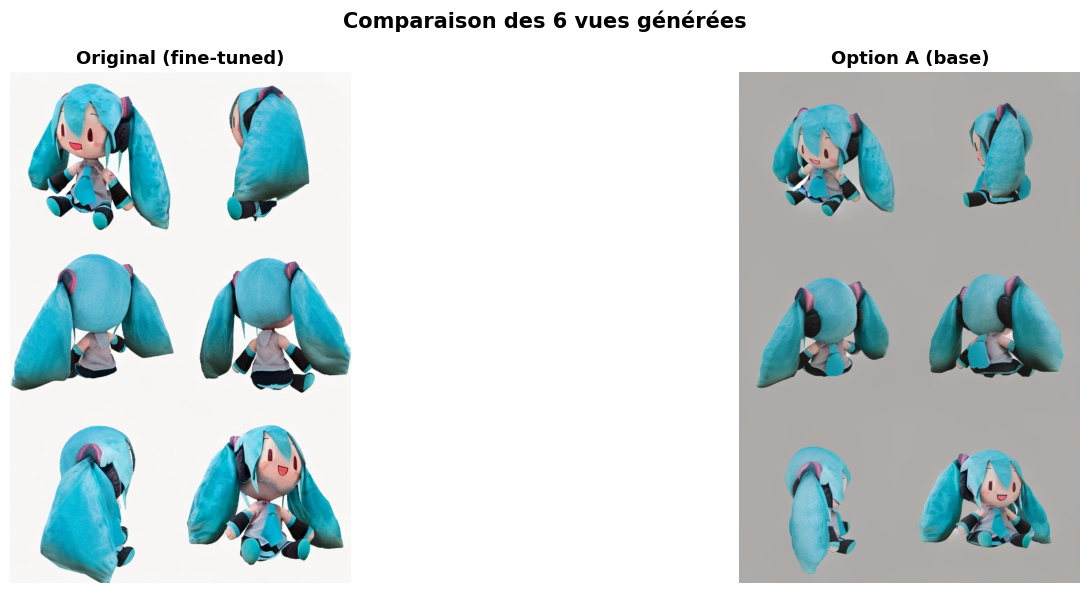


[OK] Affichage : Original



[OK] Affichage : Option A


In [9]:
# =========================================================
# 4. VISUALISATION — Comparaison côte à côte
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Video
import os

# --- Vues multi-vues ---
paths = {
    "Original (fine-tuned)": "outputs/instant-mesh-base_zero123plus_finetuned/images/hatsune_miku.png",
    "Option A (base)":       "outputs/instant-mesh-base_zero123plus_base/images/hatsune_miku.png",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, (label, path) in zip(axes, paths.items()):
    if os.path.exists(path):
        ax.imshow(np.array(Image.open(path)))
        ax.set_title(label, fontsize=13, fontweight='bold')
    else:
        # Remplacement de l'émoji par du texte pour éviter l'erreur Glyph
        ax.set_title(f"!!! FICHIER MANQUANT !!!\n{path}", color='red', fontsize=10)
        print(f"Attention : Image absente -> {path}")
    ax.axis('off')

plt.suptitle("Comparaison des 6 vues générées", fontsize=15, fontweight='bold')
plt.tight_layout()
os.makedirs('outputs/comparaisons', exist_ok=True)
plt.savefig('outputs/comparaisons/vues_comparaison.png', dpi=150)
plt.show()

# --- Vidéos 3D ---
video_paths = {
    "Original": "outputs/instant-mesh-base_zero123plus_finetuned/videos/hatsune_miku.mp4",
    "Option A":  "outputs/instant-mesh-base_zero123plus_base/videos/hatsune_miku.mp4",
}

for label, path in video_paths.items():
    if os.path.exists(path):
        print(f"\n[OK] Affichage : {label}")
        display(Video(path, embed=True, width=512))
    else:
        # Utilisation de [X] au lieu de l'émoji pour la console si besoin
        print(f"[X] Vidéo manquante : {path}")

In [3]:
!find /content/InstantMesh/outputs -maxdepth 4

/content/InstantMesh/outputs
/content/InstantMesh/outputs/comparaisons
/content/InstantMesh/outputs/comparaisons/vues_comparaison.png
/content/InstantMesh/outputs/instant-mesh-base_zero123plus_finetuned
/content/InstantMesh/outputs/instant-mesh-base_zero123plus_finetuned/images
/content/InstantMesh/outputs/instant-mesh-base_zero123plus_finetuned/videos
/content/InstantMesh/outputs/instant-mesh-base_zero123plus_finetuned/meshes
/content/InstantMesh/outputs/instant-mesh-base_zero123plus_base
/content/InstantMesh/outputs/instant-mesh-base_zero123plus_base/images
/content/InstantMesh/outputs/instant-mesh-base_zero123plus_base/videos
/content/InstantMesh/outputs/instant-mesh-base_zero123plus_base/meshes


In [11]:
!pip install lpips scikit-image "numpy==1.26.4" "scipy<1.13.0"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 25.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
  Attempting uninstall: tifffile
    Found existing installation: tifffile 2026.4.11
    Uninstalling tifffile-2026.4.11:
      Successfully uninstalled tifffile-2026.4.11
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling sci

In [3]:
import torch
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips
import pandas as pd
import os

# Forcer Colab à travailler dans le bon dossier
%cd /content/InstantMesh

# Initialisation du modèle LPIPS
loss_fn = lpips.LPIPS(net='alex')

def load_6views(path):
    img = np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0
    H, W = img.shape[0] // 3, img.shape[1] // 2
    views = []
    for row in range(3):
        for col in range(2):
            views.append(img[row*H:(row+1)*H, col*W:(col+1)*W])
    return np.stack(views)

def compute_metrics(path_ref, path_other):
    if not os.path.exists(path_ref) or not os.path.exists(path_other):
        return {'PSNR ↑': 'Erreur', 'SSIM ↑': 'Erreur', 'LPIPS ↓': f'Fichier manquant'}

    v_ref, v_other = load_6views(path_ref), load_6views(path_other)
    psnr_l, ssim_l, lpips_l = [], [], []
    for i in range(6):
        psnr_l.append(psnr(v_ref[i], v_other[i], data_range=1.0))
        ssim_l.append(ssim(v_ref[i], v_other[i], channel_axis=2, data_range=1.0))

        t1 = torch.from_numpy(v_ref[i]).permute(2,0,1).unsqueeze(0) * 2 - 1
        t2 = torch.from_numpy(v_other[i]).permute(2,0,1).unsqueeze(0) * 2 - 1
        lpips_l.append(loss_fn(t1, t2).item())

    return {'PSNR ↑': round(np.mean(psnr_l),3),
            'SSIM ↑': round(np.mean(ssim_l),4),
            'LPIPS ↓': round(np.mean(lpips_l),4)}

NOM_IMAGE = "hatsune_miku.png"

# Utilisation des CHEMINS ABSOLUS pour éviter que Colab se perde
path_ref  = f"/content/InstantMesh/outputs/instant-mesh-base_zero123plus_finetuned/images/{NOM_IMAGE}"
path_base = f"/content/InstantMesh/outputs/instant-mesh-base_zero123plus_base/images/{NOM_IMAGE}"

print("Calcul des métriques en cours...")
df = pd.DataFrame([
    {"Modèle": "Original fine-tuned (référence)", **compute_metrics(path_ref, path_ref)},
    {"Modèle": "Option A — base sans fine-tuning", **compute_metrics(path_ref, path_base)},
]).set_index("Modèle")

print("\n", df.to_string())

os.makedirs('/content/InstantMesh/outputs/comparaisons', exist_ok=True)
df.to_csv('/content/InstantMesh/outputs/comparaisons/metriques.csv')
print("\n✅ Sauvegardé dans outputs/comparaisons/metriques.csv")

/content/InstantMesh
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Calcul des métriques en cours...


/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)



                                   PSNR ↑  SSIM ↑  LPIPS ↓
Modèle                                                   
Original fine-tuned (référence)      inf  1.0000    0.000
Option A — base sans fine-tuning  10.672  0.6163    0.484

✅ Sauvegardé dans outputs/comparaisons/metriques.csv
